Consider variables x and y created from a pandas dataframe “car.csv” .
Create new column named “Age_car” (Age_car=2023-year)
For multiple linear regression problem, x contains the independent variables ( Age_car , Driven_kms , Fuel_Type , Selling_type ,
Transmission ) and y contains the dependent (Selling_Price) variable which is to be predicted.
Write a Python program to spilt x and y into training and testing datasets with a 20% split. Then create a multiple linear
regression model using the training data and print its coefficients ,intercept and mean squared error.

In [12]:
import pandas as pd
import numpy as np
df=pd.read_csv("car data.csv")
df

,Car_Name,Year,Selling_Price,Present_Price,Kms_Driven,Fuel_Type,Seller_Type,Transmission,Owner
0,ritz,2014,3.35,5.59,27000,Petrol,Dealer,Manual,0
1,sx4,2013,4.75,9.54,43000,Diesel,Dealer,Manual,0
2,ciaz,2017,7.25,9.85,6900,Petrol,Dealer,Manual,0
3,wagon r,2011,2.85,4.15,5200,Petrol,Dealer,Manual,0
4,swift,2014,4.60,6.87,42450,Diesel,Dealer,Manual,0
...,...,...,...,...,...,...,...,...,...
296,city,2016,9.50,11.60,33988,Diesel,Dealer,Manual,0
297,brio,2015,4.00,5.90,60000,Petrol,Dealer,Manual,0
298,city,2009,3.35,11.00,87934,Petrol,Dealer,Manual,0
299,city,2017,11.50,12.50,9000,Diesel,Dealer,Manual,0


In [13]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 301 entries, 0 to 300
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Car_Name       301 non-null    object 
 1   Year           301 non-null    int64  
 2   Selling_Price  301 non-null    float64
 3   Present_Price  301 non-null    float64
 4   Kms_Driven     301 non-null    int64  
 5   Fuel_Type      301 non-null    object 
 6   Seller_Type    301 non-null    object 
 7   Transmission   301 non-null    object 
 8   Owner          301 non-null    int64  
dtypes: float64(2), int64(3), object(4)
memory usage: 21.3+ KB


In [14]:
df.drop('Car_Name',axis=1,inplace=True)
df

,Year,Selling_Price,Present_Price,Kms_Driven,Fuel_Type,Seller_Type,Transmission,Owner
0,2014,3.35,5.59,27000,Petrol,Dealer,Manual,0
1,2013,4.75,9.54,43000,Diesel,Dealer,Manual,0
2,2017,7.25,9.85,6900,Petrol,Dealer,Manual,0
3,2011,2.85,4.15,5200,Petrol,Dealer,Manual,0
4,2014,4.60,6.87,42450,Diesel,Dealer,Manual,0
...,...,...,...,...,...,...,...,...
296,2016,9.50,11.60,33988,Diesel,Dealer,Manual,0
297,2015,4.00,5.90,60000,Petrol,Dealer,Manual,0
298,2009,3.35,11.00,87934,Petrol,Dealer,Manual,0
299,2017,11.50,12.50,9000,Diesel,Dealer,Manual,0


In [15]:
df["Age_car"]=2023-df["Year"]
df

,Year,Selling_Price,Present_Price,Kms_Driven,Fuel_Type,Seller_Type,Transmission,Owner,Age_car
0,2014,3.35,5.59,27000,Petrol,Dealer,Manual,0,9
1,2013,4.75,9.54,43000,Diesel,Dealer,Manual,0,10
2,2017,7.25,9.85,6900,Petrol,Dealer,Manual,0,6
3,2011,2.85,4.15,5200,Petrol,Dealer,Manual,0,12
4,2014,4.60,6.87,42450,Diesel,Dealer,Manual,0,9
...,...,...,...,...,...,...,...,...,...
296,2016,9.50,11.60,33988,Diesel,Dealer,Manual,0,7
297,2015,4.00,5.90,60000,Petrol,Dealer,Manual,0,8
298,2009,3.35,11.00,87934,Petrol,Dealer,Manual,0,14
299,2017,11.50,12.50,9000,Diesel,Dealer,Manual,0,6


In [16]:
df.drop('Year',axis=1,inplace=True)
df

,Selling_Price,Present_Price,Kms_Driven,Fuel_Type,Seller_Type,Transmission,Owner,Age_car
0,3.35,5.59,27000,Petrol,Dealer,Manual,0,9
1,4.75,9.54,43000,Diesel,Dealer,Manual,0,10
2,7.25,9.85,6900,Petrol,Dealer,Manual,0,6
3,2.85,4.15,5200,Petrol,Dealer,Manual,0,12
4,4.60,6.87,42450,Diesel,Dealer,Manual,0,9
...,...,...,...,...,...,...,...,...
296,9.50,11.60,33988,Diesel,Dealer,Manual,0,7
297,4.00,5.90,60000,Petrol,Dealer,Manual,0,8
298,3.35,11.00,87934,Petrol,Dealer,Manual,0,14
299,11.50,12.50,9000,Diesel,Dealer,Manual,0,6


In [17]:
df=pd.get_dummies(data=df,drop_first=True)
df

,Selling_Price,Present_Price,Kms_Driven,Owner,Age_car,Fuel_Type_Diesel,Fuel_Type_Petrol,Seller_Type_Individual,Transmission_Manual
0,3.35,5.59,27000,0,9,False,True,False,True
1,4.75,9.54,43000,0,10,True,False,False,True
2,7.25,9.85,6900,0,6,False,True,False,True
3,2.85,4.15,5200,0,12,False,True,False,True
4,4.60,6.87,42450,0,9,True,False,False,True
...,...,...,...,...,...,...,...,...,...
296,9.50,11.60,33988,0,7,True,False,False,True
297,4.00,5.90,60000,0,8,False,True,False,True
298,3.35,11.00,87934,0,14,False,True,False,True
299,11.50,12.50,9000,0,6,True,False,False,True


In [19]:
x=df.iloc[:,1:]
y=df["Selling_Price"]
print(x.shape)
print(y.shape)

(301, 8)
(301,)


In [22]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=2)
print(x_train.shape)
print(y_train.shape)
print(x_test.shape)
print(y_test.shape)

(240, 8)
(240,)
(61, 8)
(61,)


In [23]:
from sklearn.linear_model import LinearRegression
lr=LinearRegression()
lr.fit(x_train,y_train)
ypred=lr.predict(x_test)
print(ypred)

[10.57889241  0.71754255  4.23613904  5.17855444  9.75533583  4.20615652
  2.6748089   7.63221623  0.17032381  5.13283747  6.15727726  6.44545506
  2.11900126  7.6644102   1.91710055  1.71680788  2.02672159  1.85294787
  9.56717323  4.23076317  1.48724915  9.36189904  1.46103587  9.54572517
  0.82954545  8.32266051  1.53698563 -3.16293717  4.2127377   2.10385587
  3.42279444  3.71284702  5.54538889  7.6834828  -1.89757368  7.06591847
  8.46027656  5.77704136  6.10531922  6.52919752 16.08564344  2.07410694
  1.05462465 -0.44710144  7.06940454  6.73548589  0.98609923  7.08961114
 14.16420523  3.00434598  8.2871215  -0.87862345  8.8814273   1.15099681
  2.11848057 -0.82641923  0.69287067  9.88583992 -0.45444272 -2.41051663
 10.28627971]


In [26]:
from sklearn import metrics
MSE=metrics.mean_squared_error(y_test,ypred)
print("MSE is:",MSE)
print(lr.coef_)
print(lr.intercept_)

MSE is: 2.7506892621397556
[ 4.28802981e-01 -5.92316903e-06 -8.49009727e-01 -4.06411225e-01
  2.86056285e+00  7.03103550e-01 -1.07477347e+00 -1.50897975e+00]
6.0379348717133885


In [28]:
diff=pd.DataFrame({"actual":y_test,"predicted":ypred})
diff

,actual,predicted
99,9.65,10.578892
161,0.45,0.717543
89,4.75,4.236139
30,3.10,5.178554
232,11.45,9.755336
...,...,...
172,0.40,0.692871
94,4.00,9.885840
160,0.45,-0.454443
199,0.12,-2.410517


Write a program to create a Model using linear regression to predict the wine quality using the csv file provided named
“winequality.csv”. Do the required process in the data before making a model.
If you find any null value in “winequality.csv” then replace null value with mean value of respected columns.
Find co-efficient, intercept and mean squared error.
also Predict the quality of red wine for the following data:
fixed acidity: 8
volaƟle acidity: 0.4
citric acid: 0.40
residual sugar: 15
chlorides: 0.048
free sulfur dioxide: 40
total sulfur dioxide: 150
density: 0.99
pH: 3
sulphates: 0.45
alcohol: 10.5

In [29]:
df=pd.read_csv("wine-quality.csv")
df

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.0,0.27,0.36,20.7,0.045,45.0,170.0,1.00100,3.00,0.45,8.8,6
1,6.3,0.30,0.34,1.6,0.049,14.0,132.0,0.99400,3.30,0.49,9.5,6
2,8.1,0.28,0.40,6.9,0.050,30.0,97.0,0.99510,3.26,0.44,10.1,6
3,7.2,0.23,0.32,8.5,0.058,47.0,186.0,0.99560,3.19,0.40,9.9,6
4,7.2,0.23,0.32,8.5,0.058,47.0,186.0,0.99560,3.19,0.40,9.9,6
...,...,...,...,...,...,...,...,...,...,...,...,...
4893,6.2,0.21,0.29,1.6,0.039,24.0,92.0,0.99114,3.27,0.50,11.2,6
4894,6.6,0.32,0.36,8.0,0.047,57.0,168.0,0.99490,3.15,0.46,9.6,5
4895,6.5,0.24,0.19,1.2,0.041,30.0,111.0,0.99254,2.99,0.46,9.4,6
4896,5.5,0.29,0.30,1.1,0.022,20.0,110.0,0.98869,3.34,0.38,12.8,7


In [31]:
df.isna().sum()

fixed acidity           0
volatile acidity        0
citric acid             0
residual sugar          0
chlorides               0
free sulfur dioxide     0
total sulfur dioxide    0
density                 0
pH                      0
sulphates               0
alcohol                 0
quality                 0
dtype: int64

In [32]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4898 entries, 0 to 4897
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         4898 non-null   float64
 1   volatile acidity      4898 non-null   float64
 2   citric acid           4898 non-null   float64
 3   residual sugar        4898 non-null   float64
 4   chlorides             4898 non-null   float64
 5   free sulfur dioxide   4898 non-null   float64
 6   total sulfur dioxide  4898 non-null   float64
 7   density               4898 non-null   float64
 8   pH                    4898 non-null   float64
 9   sulphates             4898 non-null   float64
 10  alcohol               4898 non-null   float64
 11  quality               4898 non-null   int64  
dtypes: float64(11), int64(1)
memory usage: 459.3 KB


In [38]:
x=df.iloc[:,:11]
y=df["quality"]
print(x.shape)
print(y.shape)

(4898, 11)
(4898,)


In [40]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=2)
print(x_train.shape)
print(x_test.shape)
print(y_train.shape)
print(y_test.shape)

(3918, 11)
(980, 11)
(3918,)
(980,)


In [41]:
from sklearn.linear_model import LinearRegression
lr=LinearRegression()
lr.fit(x_train,y_train)
y_pred=lr.predict(x_test)
print(y_pred)

[5.59824104 6.19126593 5.99132105 4.87833603 6.66708392 6.37488384
 6.13804056 6.3009328  5.94219988 6.24840816 5.49196151 5.85174522
 5.86389593 6.37930404 5.70816963 5.85025853 5.98742589 5.47594854
 6.02278461 6.48197013 5.8646541  6.52749659 6.28701042 5.92427929
 6.55835631 5.27225737 5.10776263 6.59351759 6.09757398 6.20899199
 6.56171689 5.9206529  6.49392895 5.98633176 6.4310866  5.49296742
 6.61458006 6.28293036 6.02743702 5.2319707  5.81091796 5.43001753
 6.22684368 5.2114861  5.54853409 5.42592271 5.06886885 5.56310495
 6.03329207 6.18071438 6.63564257 5.76582638 6.09755226 6.52033506
 6.07324647 5.29387989 5.23811063 4.95114268 6.18082577 6.14268107
 5.83375527 6.58030878 5.53167546 6.34039403 5.94505792 5.65091341
 5.24569551 6.10544099 6.0103188  4.16420238 5.8175146  6.06993785
 6.10323374 6.08110184 6.03038607 5.92688719 6.62290764 5.6566047
 6.46702093 5.73365376 6.10393221 6.69888395 6.48121099 6.43491938
 6.13576643 5.6309306  6.26641312 6.47642736 5.57659177 6.47256

In [42]:
from sklearn import metrics
mse=metrics.mean_squared_error(y_test,y_pred)
print("MSE:",mse)
print("coefficient: ",lr.coef_)
print("intercept: ",lr.intercept_)

MSE: 0.5858133112405071
coefficient:  [ 1.14147505e-01 -1.92325288e+00  5.07062358e-02  1.04633216e-01
  2.75004683e-01  4.02490592e-03 -1.34038657e-04 -2.17264729e+02
  9.18336632e-01  6.96479804e-01  1.14426060e-01]
intercept:  216.30886592306814


In [43]:
print(x_test)

      fixed acidity  volatile acidity  citric acid  residual sugar  chlorides  \
3732            7.5              0.28         0.41             1.3      0.044   
2981            8.5              0.23         0.28            11.1      0.033   
1247            7.2              0.21         0.34             1.1      0.046   
1835            8.0              0.55         0.42            12.6      0.211   
4432            6.7              0.24         0.26             5.4      0.030   
...             ...               ...          ...             ...        ...   
831             7.4              0.17         0.40             5.5      0.037   
2066            7.7              0.28         0.29             4.3      0.051   
2574            6.8              0.26         0.24             1.9      0.043   
1097            6.3              0.23         0.21             5.1      0.035   
2274            7.3              0.19         0.25             1.4      0.051   

      free sulfur dioxide  

In [47]:
from sklearn.linear_model import LinearRegression
lr=LinearRegression()
lr.fit(x_train,y_train)
y_pred=lr.predict([[8,0.4,0.4,15,0.048,40,150,0.99,3,0.45,10.5]])
print(y_pred)

[7.37443442]


D:\yatrik\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


Write Python code to train a kNN classifier using the following steps:
Split the dataset X into training and testing sets with a test size of 0.3 and a random state of 42.
Initialize a kNN classifier with 5 neighbors.
Train the classifier on the training set.
Make predictions on the test set.
Calculate and print the accuracy score of the classifier.

In [54]:
import pandas as pd
import numpy as np

df=pd.read_csv("iris.csv")

df.drop('Id',axis=1,inplace=True)

df=pd.get_dummies(data=df,drop_first=True)
df


,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species_Iris-versicolor
0,5.1,3.5,1.4,0.2,False
1,4.9,3.0,1.4,0.2,False
2,4.7,3.2,1.3,0.2,False
3,4.6,3.1,1.5,0.2,False
4,5.0,3.6,1.4,0.2,False
...,...,...,...,...,...
95,5.7,3.0,4.2,1.2,True
96,5.7,2.9,4.2,1.3,True
97,6.2,2.9,4.3,1.3,True
98,5.1,2.5,3.0,1.1,True


In [62]:
x=df.iloc[:,0:4]
y=df["Species_Iris-versicolor"]
print(x.shape)
print(y.shape)

from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)
print(x_train.shape)
print(y_train.shape)
print(x_test.shape)
print(y_test.shape)

from sklearn.neighbors import KNeighborsClassifier
nn=KNeighborsClassifier(n_neighbors=3)
model=nn.fit(x_train,y_train)
ypred=model.predict(x_test)
print(ypred)

from sklearn import metrics
MSE=metrics.mean_squared_error(y_test,ypred)
print("MSE is:",MSE)
print(lr.coef_)
print(lr.intercept_)

from sklearn.metrics import accuracy_score
print("Accuracy score:",accuracy_score(y_test,ypred))

(100, 4)
(100,)
(80, 4)
(80,)
(20, 4)
(20,)
[ True  True  True False False False False  True False False False False
  True False  True False  True  True False False]
MSE is: 0.0
[ 1.14147505e-01 -1.92325288e+00  5.07062358e-02  1.04633216e-01
  2.75004683e-01  4.02490592e-03 -1.34038657e-04 -2.17264729e+02
  9.18336632e-01  6.96479804e-01  1.14426060e-01]
216.30886592306814
Accuracy score: 1.0


In [60]:
diff=pd.DataFrame({"Actual":y_test,"Predicted":ypred})
diff

,Actual,Predicted
83,True,True
53,True,True
70,True,True
45,False,False
44,False,False
39,False,False
22,False,False
80,True,True
10,False,False
0,False,False


You are tasked with using the k-Nearest Neighbors (kNN) algorithm to classify whether patients have diabetes or not based on
certain diagnostic measurements. You have been provided with diabetes.csv file. The datasets consist of several medical
predictor (independent) variables and one target (dependent) variable, Outcome. Independent variables include the number of
pregnancies the patient has had, their BMI, insulin level, age, and so on. Also perform Model Performance Analysis using
confusion matrix.

In [63]:
df=pd.read_csv("diabetes.csv")
df

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1
...,...,...,...,...,...,...,...,...,...
763,10,101,76,48,180,32.9,0.171,63,0
764,2,122,70,27,0,36.8,0.340,27,0
765,5,121,72,23,112,26.2,0.245,30,0
766,1,126,60,0,0,30.1,0.349,47,1


In [68]:
x=df.iloc[:,:8]
y=df["Outcome"]
print(x.shape)
print(y.shape)

from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=41)
print(x_train.shape)
print(y_train.shape)
print(x_test.shape)
print(y_test.shape)



from sklearn.neighbors import KNeighborsClassifier
nn=KNeighborsClassifier(n_neighbors=15)
model=nn.fit(x_train,y_train)
ypred=model.predict(x_test)
print(ypred)

from sklearn.metrics import confusion_matrix
cm=confusion_matrix(y_test,ypred)
print(cm)

(768, 8)
(768,)
(614, 8)
(614,)
(154, 8)
(154,)
[0 0 1 1 0 1 0 0 0 0 0 0 0 0 0 0 0 0 1 0 1 0 0 0 0 0 0 0 0 0 0 1 0 1 0 0 0
 0 0 1 0 0 1 0 1 0 1 0 0 1 0 1 0 0 1 0 0 0 1 0 0 1 1 1 0 0 0 1 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 1 1 0 0 1 0 1 0 0 0 0 1 0 0 0 0 0 0 0 1 0
 0 1 1 0 1 1 0 0 1 1 1 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 1 0 0 0 0 1 1 0 0 0
 0 1 0 0 0 0]
[[90  9]
 [26 29]]


The task involves building a Decision Tree classifier to predict whether to play tennis based on weather conditions. The dataset
used for this task is the PlayTennis dataset, which contains information about various weather attributes such as outlook,
temperature, humidity, and wind, along with the corresponding decision to play tennis or not. Use PlayTennis.csv for dataset.

In [75]:
df=pd.read_csv("Decisiontree_Sports.csv")
df

,Day,Weather,Temperature,Humidity,Wind,Play_Sports?
0,Day 1,Sunny,Hot,High,Weak,No
1,Day 2,Sunny,Hot,High,Strong,No
2,Day 3,Cloudy,Hot,High,Weak,Yes
3,Day 4,Rain,Mild,High,Weak,Yes
4,Day 5,Rain,Cool,Normal,Weak,Yes
5,Day 6,Rain,Cool,Normal,Strong,No
6,Day 7,Cloudy,Cool,Normal,Strong,Yes
7,Day 8,Sunny,Mild,High,Weak,No
8,Day 9,Sunny,Cool,Normal,Weak,Yes
9,Day 10,Rain,Mild,Normal,Weak,Yes


In [76]:
df.drop("Day",inplace=True,axis=1)
df

,Weather,Temperature,Humidity,Wind,Play_Sports?
0,Sunny,Hot,High,Weak,No
1,Sunny,Hot,High,Strong,No
2,Cloudy,Hot,High,Weak,Yes
3,Rain,Mild,High,Weak,Yes
4,Rain,Cool,Normal,Weak,Yes
5,Rain,Cool,Normal,Strong,No
6,Cloudy,Cool,Normal,Strong,Yes
7,Sunny,Mild,High,Weak,No
8,Sunny,Cool,Normal,Weak,Yes
9,Rain,Mild,Normal,Weak,Yes


In [77]:
df["Weather"]=np.where(df["Weather"]=="Rain",2,np.where(df["Weather"]=="Cloudy",1,0))
df["Temperature"]=np.where(df["Temperature"]=="Cool",2,np.where(df["Temperature"]=="Mild",1,0))
df["Humidity"]=np.where(df["Humidity"]=="Normal",1,0)
df["Wind"]=np.where(df["Wind"]=="Strong",1,0)
df["Play_Sports?"]=np.where(df["Play_Sports?"]=="Yes",1,0)
df

,Weather,Temperature,Humidity,Wind,Play_Sports?
0,0,0,0,0,0
1,0,0,0,1,0
2,1,0,0,0,1
3,2,1,0,0,1
4,2,2,1,0,1
5,2,2,1,1,0
6,1,2,1,1,1
7,0,1,0,0,0
8,0,2,1,0,1
9,2,1,1,0,1


In [81]:
x=df.iloc[:,:4]
y=df["Play_Sports?"]
print(x.shape)
print(y.shape)
from sklearn.tree import DecisionTreeClassifier
dtree=DecisionTreeClassifier(criterion="entropy")
model=dtree.fit(x,y)
ypred=model.predict(x)
print(ypred)

(14, 4)
(14,)
[0 0 1 1 1 0 1 0 1 1 1 1 1 0]


In [82]:
diff=pd.DataFrame({"Actual":y,"predicted":ypred})
diff

,Actual,predicted
0,0,0
1,0,0
2,1,1
3,1,1
4,1,1
5,0,0
6,1,1
7,0,0
8,1,1
9,1,1


Write a python program for following tasks -
Make sure all the required libraries are imported at the beginning of the Jupyter Notebook.
a)Load the windpower dataset into the notebook.
b)Check records for any missing values and remove them permanently using appropriate method.
c)Treat windspeed as the independent variable and power as the dependent variable. Split the dataset into training (75%) and
testing (25%) sets using random state of 42.
d)Use scikit-learn to train polynomial regression models of degrees 3, 4, 5, and 6.
e)Predict power values on the test set and print the Mean Squared Error (MSE) and R2 score (coefficient of determinaƟon) for
each polynomial degree.
f)Plot actual vs. predicted power values for all polynomial degrees on the same graph for comparison and label the plot
accordingly.
g)Create a plot showing MSE vs. polynomial degree. Which degree has the lowest MSE? Write in the comment.
h)Print the coefficients and intercept for each trained polynomial regression model.

In [91]:
df=pd.read_csv("windpower.csv")
df

,Power (kW),Wind speed (m/s)
0,0.0,0.000
1,0.0,0.125
2,0.0,0.150
3,0.0,0.225
4,0.0,0.275
...,...,...
495,0.0,24.775
496,0.0,24.850
497,0.0,24.875
498,0.0,24.950


In [92]:
df.isna().sum()

Power (kW)          3
Wind speed (m/s)    5
dtype: int64

In [95]:
df.dropna(inplace=True)
df

,Power (kW),Wind speed (m/s)
0,0.0,0.000
1,0.0,0.125
2,0.0,0.150
3,0.0,0.225
4,0.0,0.275
...,...,...
495,0.0,24.775
496,0.0,24.850
497,0.0,24.875
498,0.0,24.950


In [96]:
df.isna().sum()

Power (kW)          0
Wind speed (m/s)    0
dtype: int64

In [97]:
x=df[["Wind speed (m/s)"]]
y=df["Power (kW)"]
print(x.shape)
print(y.shape)

(492, 1)
(492,)


In [113]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn import metrics
from sklearn.preprocessing import PolynomialFeatures

d={}
y_pred_pred={}
x_test_original={}
y_test_test={}
for i in range(3,7):
    poly=PolynomialFeatures(degree=i)
    x_poly=poly.fit_transform(x)

    x_train,x_test,y_train,y_test=train_test_split(x_poly,y,test_size=0.25,random_state=42)
    print(x_train.shape)
    print(y_train.shape)
    print(x_test.shape)
    print(y_test.shape)
    
    lr=LinearRegression()
    lr.fit(x_train,y_train)
    ypred=lr.predict(x_test)
    print(ypred.shape)
    d[i]=ypred
    mse=metrics.mean_squared_error(y_test,ypred)
    print("MSE for random state ",i," is:",mse)
    r2_score=metrics.r2_score(y_test,ypred)
    print("R2 score for random state ",i," is:",r2_score)
    y_pred_pred[i]=ypred
    y_test_test[i]=y_test
    x_test_original[i] = x_test[:, 1] 
print(x_test_test[3].shape)
print(x_test_test[5])
import matplotlib.pyplot as plt
for i in range(3,7):
    plt.scatter(x_test_test[i],y_test_test[i],color="blue",label="actual")
    plt.plot(x_test_test[i],y_pred_pred[i],color="red",label="Predict")
plt.xlabel("Wind speed (m/s)")
plt.ylabel("Power (kW)")
plt.legend()
plt.grid(True)
plt.plot()

(369, 4)
(369,)
(123, 4)
(123,)
(123,)
MSE for random state  3  is: 270.0250095299939
R2 score for random state  3  is: 0.853926414197384
(369, 5)
(369,)
(123, 5)
(123,)
(123,)
MSE for random state  4  is: 209.3184510784698
R2 score for random state  4  is: 0.8867664266472872
(369, 6)
(369,)
(123, 6)
(123,)
(123,)
MSE for random state  5  is: 212.4228861336371
R2 score for random state  5  is: 0.8850870416111051
(369, 7)
(369,)
(123, 7)
(123,)
(123,)
MSE for random state  6  is: 169.17010419375612
R2 score for random state  6  is: 0.9084852037476209


KeyError: 3

--- Training Models ---
Degree 3: MSE = 270.03, R2 = 0.8539
Coefficient for  3 th degree is [  0.         -12.17377575   1.8029668   -0.04960797]
Intercept for  3 th degree is 17.77534233104121
Degree 4: MSE = 209.32, R2 = 0.8868
Coefficient for  4 th degree is [ 0.         -2.10494179 -0.036268    0.06568915 -0.00231786]
Intercept for  4 th degree is 5.863727006159003
Degree 5: MSE = 212.42, R2 = 0.8851
Coefficient for  5 th degree is [ 0.00000000e+00 -6.91240269e-01 -4.31617906e-01  1.07790122e-01
 -4.21343552e-03  3.03911610e-05]
Intercept for  5 th degree is 4.739942925790281
Degree 6: MSE = 169.17, R2 = 0.9085
Coefficient for  6 th degree is [ 0.00000000e+00  2.39063436e+01 -1.00641730e+01  1.62983192e+00
 -1.17629556e-01  4.01186376e-03 -5.30687163e-05]
Intercept for  6 th degree is -9.916620599848493

--- Generating Plots ---


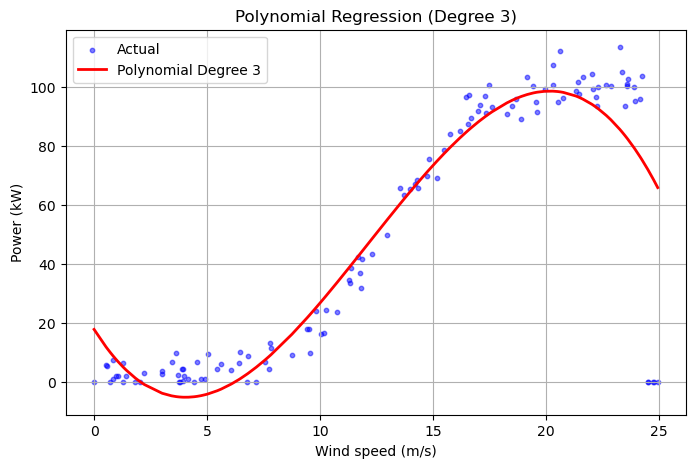

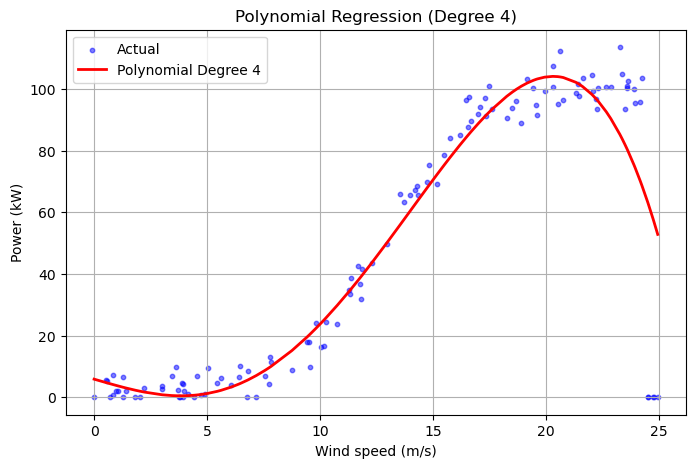

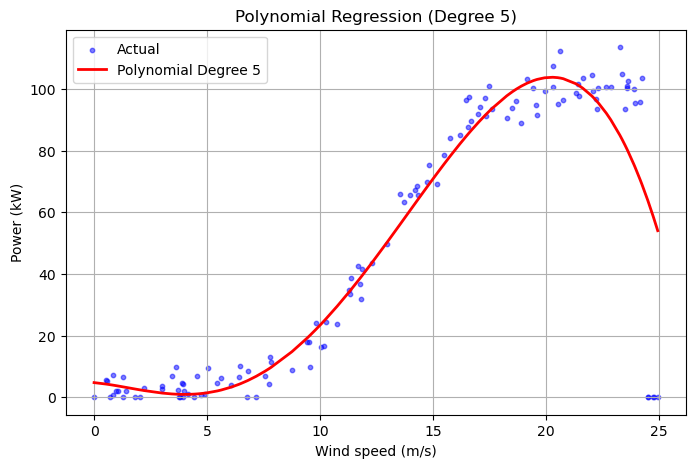

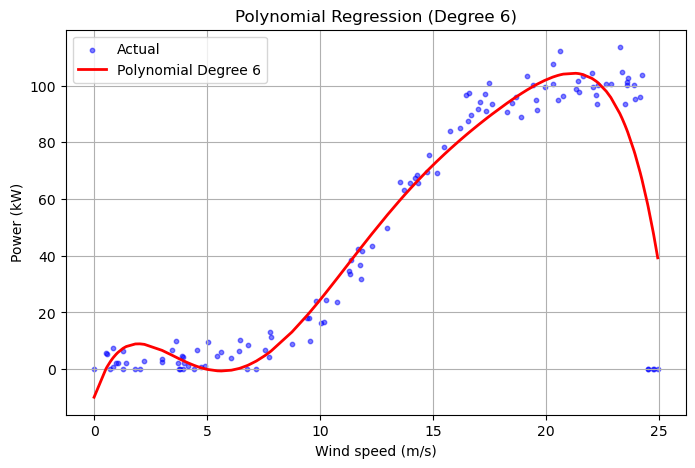

C:\Users\Administrator\AppData\Local\Temp\ipykernel_3712\273296495.py:71: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


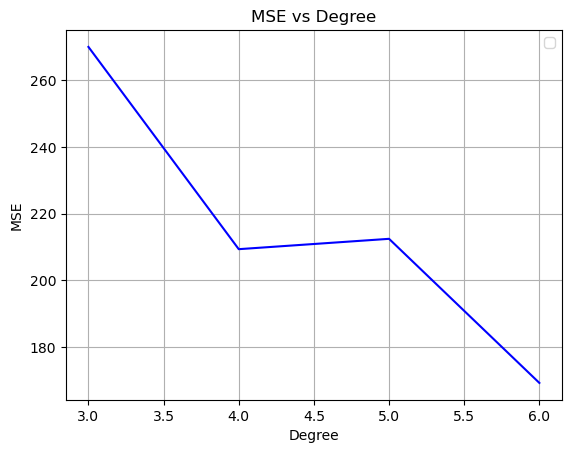

In [117]:
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn import metrics
from sklearn.preprocessing import PolynomialFeatures
import matplotlib.pyplot as plt

d = {}
y_pred_pred = {}
x_test_test = {}
y_test_test = {}
mse_mse=[]
# Dictionary to hold the 1D wind speed data for plotting
x_test_original = {}

print("--- Training Models ---")
for i in range(3, 7):
    # Polynomial features
    poly = PolynomialFeatures(degree=i)
    x_poly = poly.fit_transform(x)

    # Split data
    x_train, x_test, y_train, y_test = train_test_split(
        x_poly, y, test_size=0.25, random_state=42
    )

    # Train Model
    lr = LinearRegression()
    lr.fit(x_train, y_train)
    ypred = lr.predict(x_test)

    # Store results
    d[i] = ypred
    y_pred_pred[i] = ypred
    y_test_test[i] = y_test
    
    # Store the first column of the poly features (original X) for proper plotting
    x_test_original[i] = x_test[:, 1] 

    mse = metrics.mean_squared_error(y_test, ypred)
    r2 = metrics.r2_score(y_test, ypred)
    print(f"Degree {i}: MSE = {mse:.2f}, R2 = {r2:.4f}")
    mse_mse.append(mse)
    print("Coefficient for ",i,"th degree is",lr.coef_)
    print("Intercept for ",i,"th degree is",lr.intercept_)
    
print("\n--- Generating Plots ---")
for i in range(3, 7):
    plt.figure(figsize=(8, 5))
    
    # --- FIX: Sort data for proper line plotting ---
    sort_axis = np.argsort(x_test_original[i])
    x_sorted = x_test_original[i][sort_axis]
    y_pred_sorted = y_pred_pred[i][sort_axis]
    # -----------------------------------------------

    plt.scatter(x_test_original[i], y_test_test[i], color="blue", label="Actual", s=10, alpha=0.5)
    plt.plot(x_sorted, y_pred_sorted, color="red", label=f"Polynomial Degree {i}", linewidth=2)
    
    plt.xlabel("Wind speed (m/s)")
    plt.ylabel("Power (kW)")
    plt.title(f"Polynomial Regression (Degree {i})")
    plt.legend()
    plt.grid(True)
    plt.show()

plt.plot([3,4,5,6],mse_mse,color="blue")
plt.xlabel("Degree")
plt.ylabel("MSE")
plt.title("MSE vs Degree")
plt.legend()
plt.grid(True)
plt.show()

Write Python code to train a Decision Tree Classifier using the following steps:
a)Assume a sample dataset is already loaded and corresponding features and labels are already defined in the environment.
b)Split the dataset into training and tesƟng sets using 75% of the data for training and set random state of 10.
c)IniƟalize an entropy-based Decision Tree Classifier with maximum depth of 3. Use this model to make predicƟons on the test
data.
d)Print confusion matrix and accuracy score of the classifier.

In [ ]:
import pandas as pd
import numpy as np
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix,accuracy_score

df=pd.read_csv("sample.csv")
x=df.iloc[:,:4]
y=df.iloc["Dependent"]
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.25,random_state=10)
dtree=DecisionTreeClassifier(criterion="entropy")
model=dtree.fit(x_train,y_train)
ypred=model.predict(x_test)
cm=confusion_matrix(y_test,ypred)
print(cm)
ac=accuracy_score(y_test,ypred)
print(ac)

Random Forest Classifier Implementation
Write Python code to implement a Random Forest Classifier using the following instructions:
Initialize the classifier with:
n_estimators = 100
random_state = 42
Train the model using training data.
Predict class labels for test data.
Evaluate the model by calculating:
Confusion Matrix
Accuracy score

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix,accuracy_score
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)
rfc=RandomForestClassifier(n_estimators=100)
rfc.fit(x_train,y_train)
ypred=rfc.predict(x_test)
ac=accuracy_score(y_test,ypred)
cm=confusion_matrix(y_test,ypred)